In [14]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict

In [15]:
load_dotenv()

True

In [42]:
model=ChatGoogleGenerativeAI(model='gemini-2.5-flash')

In [46]:
class Blogstate(TypedDict):
    title:str
    outline:str
    content:str
    score:str

In [47]:
def create_outline(state: Blogstate) -> Blogstate:

    title = state["title"]

    prompt = f"""
    Generate a detailed outline for a blog on the topic: {title}
    """

    response = model.invoke(prompt)

    outline = response.content

    if isinstance(outline, list):
        outline = "".join(
            block.get("text", "")
            for block in outline
            if isinstance(block, dict)
        )

    state["outline"] = outline

    return state

In [48]:
def create_blog(state:Blogstate)->Blogstate:

    title=state['title']
    outline=state['outline']

    prompt=f'Write a detailed blog onn the title- {title} using the following outline\n {outline}'

    content=model.invoke(prompt).content
    state['content']=content


    return state

In [49]:
def evaluate_blog(state: Blogstate) -> Blogstate:

    title = state["title"]
    outline = state["outline"]

    prompt = f"""
    Evaluate the blog outline below.
    Give a score between 1 and 10.

    Blog title: {title}

    Outline:
    {outline}

    Return only the score.
    """

    score = model.invoke(prompt).content

    state["score"] = score

    return state

In [50]:
graph=StateGraph(Blogstate)

graph.add_node('create_outline',create_outline)

graph.add_node('create_blog',create_blog)

graph.add_node('evaluate_blog',evaluate_blog)

graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog','evaluate_blog')
graph.add_edge('evaluate_blog',END)

workflow=graph.compile()

In [51]:
initial_state = {
    "title": "Beauty of India"
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Beauty of India', 'outline': 'Here\'s a detailed outline for a blog post on the topic "Beauty of India," designed to be engaging, informative, and visually evocative.\n\n---\n\n## Blog Title Options:\n*   The Kaleidoscope of Wonders: Unveiling the Enduring Beauty of India\n*   India\'s Soul: A Tapestry of Beauty, Culture, and Spirit\n*   Beyond the Postcards: Discovering the True Beauty of India\n*   From Himalayas to Backwaters: A Journey Through India\'s Breathtaking Beauty\n\n---\n\n## Blog Outline: The Kaleidoscope of Wonders: Unveiling the Enduring Beauty of India\n\n**I. Introduction: The Grand Overture**\n    *   **A. Hook:** Start with a sensory description – the immediate feeling or impression of India (e.g., "a symphony of sounds, colors, and aromas," "a land that awakens all your senses").\n    *   **B. Brief Overview:** Introduce India as a subcontinent of unparalleled diversity – geographical, cultural, historical, and spiritual.\n    *   **C. Thesis Statement:*

In [52]:
final_state["score"]

'10'

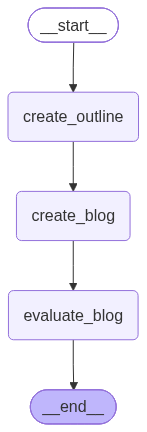

In [53]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))